# Score-by-Outcome Analysis

For a given run folder, joins the reranker scores (`scores.json` per problem) with the evaluation outcomes (`eval_results.json`) and produces a boxplot showing reranker score distributions broken down by outcome.

In [1]:
# Parameters — change this to point at any run folder
RUN_DIR = "../runs/Qwen3-Coder-30B-A3B-Instruct-FP8_level2_triton_reranked2f7"

In [2]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
def load_run(run_dir: str) -> pd.DataFrame:
    root = Path(run_dir)

    with open(root / "eval_results.json") as f:
        eval_results = json.load(f)

    rows = []
    for problem_dir in sorted(root.glob("problem_*"), key=lambda p: int(p.name.split("_")[1])):
        scores_path = problem_dir / "scores.json"
        if not scores_path.exists():
            continue

        with open(scores_path) as f:
            scores_data = json.load(f)

        problem_id = problem_dir.name.split("_")[1]  # "1", "2", ...
        best_filename = scores_data["best"]
        best_score = scores_data["scores"][best_filename]

        if problem_id not in eval_results:
            continue

        # eval_results has exactly one evaluated entry per problem
        eval_entry = eval_results[problem_id][0]
        compiled = eval_entry["compiled"]
        correctness = eval_entry["correctness"]

        if not compiled:
            outcome = "Does Not Compile"
        elif not correctness:
            outcome = "Compiles (Incorrect)"
        else:
            outcome = "Compiles + Correct"

        rows.append({
            "problem_id": int(problem_id),
            "best_sample": best_filename,
            "score": best_score,
            "compiled": compiled,
            "correctness": correctness,
            "outcome": outcome,
        })

    return pd.DataFrame(rows)


df = load_run(RUN_DIR)
print(f"Loaded {len(df)} problems from {Path(RUN_DIR).name}")
df.head()

Loaded 100 problems from Qwen3-Coder-30B-A3B-Instruct-FP8_level2_triton_reranked2f7


,problem_id,best_sample,score,compiled,correctness,outcome
0,1,level_2_problem_1_sample_6_kernel.py,0.507812,True,False,Compiles (Incorrect)
1,2,level_2_problem_2_sample_0_kernel.py,0.562500,True,True,Compiles + Correct
2,3,level_2_problem_3_sample_9_kernel.py,0.371094,True,True,Compiles + Correct
3,4,level_2_problem_4_sample_1_kernel.py,0.699219,True,False,Compiles (Incorrect)
4,5,level_2_problem_5_sample_5_kernel.py,0.679688,True,True,Compiles + Correct


In [4]:
# Outcome counts
print(df["outcome"].value_counts().to_string())

outcome
Compiles (Incorrect)    59
Compiles + Correct      37
Does Not Compile         4


In [5]:
# Summary statistics per outcome
df.groupby("outcome")["score"].describe().round(4)

,count,mean,std,min,25%,50%,75%,max
outcome,,,,,,,,
Compiles (Incorrect),59.0,0.4736,0.1871,0.1025,0.2812,0.4805,0.6035,0.9375
Compiles + Correct,37.0,0.6050,0.1804,0.1670,0.5352,0.6406,0.7109,0.8711
Does Not Compile,4.0,0.3638,0.2069,0.1641,0.1978,0.3604,0.5264,0.5703


/tmp/ipykernel_62916/1735687530.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_62916/1735687530.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


Saved to ../runs/Qwen3-Coder-30B-A3B-Instruct-FP8_level2_triton_reranked2f7/score_by_outcome.png


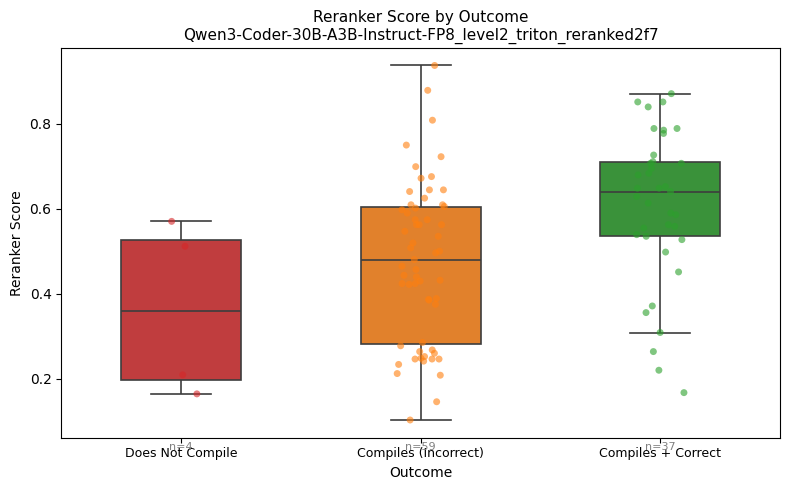

In [6]:
order = ["Does Not Compile", "Compiles (Incorrect)", "Compiles + Correct"]
palette = {"Does Not Compile": "#d62728", "Compiles (Incorrect)": "#ff7f0e", "Compiles + Correct": "#2ca02c"}

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df, x="outcome", y="score",
    order=order, palette=palette,
    width=0.5, linewidth=1.2, fliersize=0,
    ax=ax,
)
sns.stripplot(
    data=df, x="outcome", y="score",
    order=order, palette=palette,
    size=5, alpha=0.6, jitter=True, ax=ax,
)

ax.set_title(f"Reranker Score by Outcome\n{Path(RUN_DIR).name}", fontsize=11)
ax.set_xlabel("Outcome")
ax.set_ylabel("Reranker Score")
ax.tick_params(axis="x", labelsize=9)

# Annotate N per category
counts = df["outcome"].value_counts()
for i, cat in enumerate(order):
    n = counts.get(cat, 0)
    ax.text(i, ax.get_ylim()[0] - 0.01, f"n={n}", ha="center", va="top", fontsize=8, color="grey")

plt.tight_layout()
out_path = Path(RUN_DIR) / "score_by_outcome.png"
plt.savefig(out_path, dpi=150)
print(f"Saved to {out_path}")
plt.show()